# A1 — Minimal Self-Attention (NumPy)

**How to use this notebook (run order):**
1) Run **Cell 2** (Setup + data generator)
2) Run **Cell 3** (Softmax / broadcasting sanity check)
3) Run **Cell 5** (Instrumented training + plots)
4) Run **Cell 8** (Experiment A template — optional but recommended)
5) Run **Cell 9** (Test evaluation + decoded examples)

**Deliverables (what your report must include):**
- Failure analysis: what broke in the naive softmax + why (use Cell 3 evidence)
- A stable training run + loss curve
- At least one controlled ablation/fix experiment with hypothesis → method → result → interpretation
- Inspection: show at least one attention matrix and interpret it

In [2]:
import numpy as np

def generate_argmax_sample(dim=4, value_range=(0, 10), seed=None):
    """Toy task: input x is length-dim ints; target y repeats argmax(x)."""
    if seed is not None:
        np.random.seed(seed)
    x = np.random.randint(value_range[0], value_range[1], size=(dim,))
    max_val = np.max(x)
    y = np.full((dim,), max_val)
    return x, y


def make_dataset(num_samples=1000, dim=4, value_range=(0, 10), seed=0):
    """Simple fixed-length dataset (used for quick sanity checks)."""
    rng = np.random.default_rng(seed)
    dataset = []
    for _ in range(num_samples):
        x = rng.integers(value_range[0], value_range[1], size=(dim,))
        y = np.full((dim,), int(np.max(x)))
        dataset.append((x, y))
    return dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Shared functions (used by all cells below)
# ============================================================

# ----------------------------
# Core self-attention functions
# ----------------------------

def row_softmax(scores: np.ndarray) -> np.ndarray:
    """Row-wise softmax (numerically stable)."""
    scores = scores - np.max(scores, axis=1, keepdims=True)
    # Subtract max for numerical stability: exp(0)=1 is the largest value.
    exp_scores = np.exp(scores)
    # keepdims=True keeps shape (n,1) so (n,n)/(n,1) divides each row by its own sum.
    # If you drop keepdims, the sum becomes shape (n,) and (n,n)/(n,) broadcasts across columns (wrong).
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def row_softmax_buggy(scores: np.ndarray) -> np.ndarray:
    """Buggy softmax: missing keepdims — broadcasts across columns instead of rows."""
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    # shape (n,) instead of (n,1) → (n,n)/(n,) divides each COLUMN by a different row's sum
    return exp_scores / np.sum(exp_scores, axis=1)


def attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=False, softmax_fn=None):
    """Single-head self-attention + output projection."""
    if softmax_fn is None:
        softmax_fn = row_softmax
    d_k = W_Q.shape[1]
    Q = hidden_layer @ W_Q
    K = hidden_layer @ W_K
    V = hidden_layer @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    A = softmax_fn(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    cache = {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}
    return H, cache


def mse(pred, target):
    diff = pred - target
    return np.mean(diff * diff)


def attention_step(W_Q, W_K, W_V, W_H, hidden_layer, target, lr=1e-3, clip=1.0, softmax_fn=None):
    """One SGD step on a single sequence; returns loss + cache + gradient norms."""
    pred, cache = attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=True, softmax_fn=softmax_fn)
    loss = mse(pred, target)

    dH = (2.0 / pred.size) * (pred - target)

    Z = cache["Z"]
    A = cache["A"]
    V = cache["V"]
    Q = cache["Q"]
    K = cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T

    dV = A.T @ dZ
    dA = dZ @ V.T

    # Backprop through row-softmax: dS = A * (dA - sum(dA * A))
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))

    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)

    dW_Q = hidden_layer.T @ dQ
    dW_K = hidden_layer.T @ dK
    dW_V = hidden_layer.T @ dV

    grad_norms = {
        "W_Q": float(np.linalg.norm(dW_Q)),
        "W_K": float(np.linalg.norm(dW_K)),
        "W_V": float(np.linalg.norm(dW_V)),
        "W_H": float(np.linalg.norm(dW_H)),
    }

    dW_Q = np.clip(dW_Q, -clip, clip)
    dW_K = np.clip(dW_K, -clip, clip)
    dW_V = np.clip(dW_V, -clip, clip)
    dW_H = np.clip(dW_H, -clip, clip)

    W_Q = W_Q - lr * dW_Q
    W_K = W_K - lr * dW_K
    W_V = W_V - lr * dW_V
    W_H = W_H - lr * dW_H

    return W_Q, W_K, W_V, W_H, loss, cache, grad_norms


def make_hidden_and_target(x_raw, y_raw, W_embed, scale=10.0):
    """Embed scalars into d_model; scaling keeps numbers small/stable."""
    x = (np.array(x_raw, dtype=np.float64).reshape(-1, 1)) / scale
    y = (np.array(y_raw, dtype=np.float64).reshape(-1, 1)) / scale
    hidden_layer = x @ W_embed
    target = y @ W_embed
    return hidden_layer, target


def decode_embedding_to_scalar(embedded, W_embed, scale=10.0):
    """Project embedded vectors back to scalar (least-squares along W_embed direction)."""
    w = W_embed.reshape(-1)
    denom = float(w @ w) + 1e-12
    scalars = (embedded @ w) / denom
    return scalars * scale


def attention_row_entropy(A: np.ndarray) -> float:
    """Mean entropy across rows of attention matrix A."""
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    H = -np.sum(P * np.log(P), axis=1)
    return float(np.mean(H))


def inspect_cache(cache, max_rows=8):
    """Print a compact view of internals for inspection."""
    scores = cache["scores"]
    A = cache["A"]
    H = cache["H"]
    n = min(max_rows, scores.shape[0])
    print("scores (scaled dot-product):")
    print(scores[:n, :n])
    print("\nA (attention weights, rows sum to 1):")
    print(A[:n, :n])
    print(f"\nmean row entropy(A): {attention_row_entropy(A):.4f} (higher ≈ more uniform)")
    print("\nH (output, embedded):")
    print(H[:n])


# ----------------------------
# Experiment helpers (temperature scaling + split learning rates)
# ----------------------------

def attention_forward_alpha(hidden_layer, W_Q, W_K, W_V, W_H, alpha=1.0, return_cache=False):
    """Forward pass with temperature scaling on attention scores."""
    d_k = W_Q.shape[1]
    Q = hidden_layer @ W_Q
    K = hidden_layer @ W_K
    V = hidden_layer @ W_V
    scores = alpha * (Q @ K.T) / np.sqrt(d_k)
    A = row_softmax(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    cache = {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}
    return H, cache


def attention_step_alpha(W_Q, W_K, W_V, W_H, hidden_layer, target, alpha=1.0, lr=1e-3, clip=1.0):
    """One SGD step with temperature scaling."""
    pred, cache = attention_forward_alpha(hidden_layer, W_Q, W_K, W_V, W_H, alpha=alpha, return_cache=True)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)

    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T

    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))

    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)

    dW_Q = hidden_layer.T @ dQ
    dW_K = hidden_layer.T @ dK
    dW_V = hidden_layer.T @ dV

    dW_Q = np.clip(dW_Q, -clip, clip)
    dW_K = np.clip(dW_K, -clip, clip)
    dW_V = np.clip(dW_V, -clip, clip)
    dW_H = np.clip(dW_H, -clip, clip)

    W_Q = W_Q - lr * dW_Q
    W_K = W_K - lr * dW_K
    W_V = W_V - lr * dW_V
    W_H = W_H - lr * dW_H
    return W_Q, W_K, W_V, W_H, float(loss)


def attention_step_split_lr(W_Q, W_K, W_V, W_H, hidden_layer, target,
                            alpha=1.0, lr_qk=1e-3, lr_vh=1e-3, clip=1.0):
    """One SGD step with separate learning rates for Q/K vs V/H."""
    pred, cache = attention_forward_alpha(hidden_layer, W_Q, W_K, W_V, W_H, alpha=alpha, return_cache=True)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)

    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T

    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))

    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)

    dW_Q = hidden_layer.T @ dQ
    dW_K = hidden_layer.T @ dK
    dW_V = hidden_layer.T @ dV

    grad_norms = {
        "W_Q": float(np.linalg.norm(dW_Q)),
        "W_K": float(np.linalg.norm(dW_K)),
        "W_V": float(np.linalg.norm(dW_V)),
        "W_H": float(np.linalg.norm(dW_H)),
    }

    dW_Q = np.clip(dW_Q, -clip, clip)
    dW_K = np.clip(dW_K, -clip, clip)
    dW_V = np.clip(dW_V, -clip, clip)
    dW_H = np.clip(dW_H, -clip, clip)

    W_Q = W_Q - lr_qk * dW_Q
    W_K = W_K - lr_qk * dW_K
    W_V = W_V - lr_vh * dW_V
    W_H = W_H - lr_vh * dW_H

    return W_Q, W_K, W_V, W_H, float(loss), cache, grad_norms


def train_and_evaluate(alpha=1.0, epochs=300, lr=1e-3, lr_qk=None, lr_vh=None,
                       clip=1.0, seed=0, max_test_samples=50):
    """Train from scratch with optional split learning rates. Returns dict with all metrics + weights."""
    if lr_qk is None or lr_vh is None:
        lr_qk = lr
        lr_vh = lr

    d_model = W_embed.shape[1]
    rng = np.random.default_rng(seed)
    init_scale = 0.1
    wq = init_scale * rng.standard_normal((d_model, d_model))
    wk = init_scale * rng.standard_normal((d_model, d_model))
    wv = init_scale * rng.standard_normal((d_model, d_model))
    wh = init_scale * rng.standard_normal((d_model, d_model))

    loss_hist = []
    entropy_hist = []
    grad_norm_hist = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

    for _ in range(epochs):
        ep_losses = []
        ep_entropies = []
        ep_gnorms = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

        for x_raw, y_raw in train_set:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed)
            wq, wk, wv, wh, loss, cache, grad_norms = attention_step_split_lr(
                wq, wk, wv, wh, hidden, target,
                alpha=alpha, lr_qk=lr_qk, lr_vh=lr_vh, clip=clip,
            )
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_entropies.append(attention_row_entropy(cache["A"]))
                for k in ep_gnorms:
                    ep_gnorms[k].append(grad_norms[k])

        loss_hist.append(float(np.mean(ep_losses)) if ep_losses else float("nan"))
        entropy_hist.append(float(np.mean(ep_entropies)) if ep_entropies else float("nan"))
        for k in grad_norm_hist:
            grad_norm_hist[k].append(float(np.mean(ep_gnorms[k])) if ep_gnorms[k] else float("nan"))

    test_losses = []
    test_entropies = []
    for x_raw, y_raw in test_set[:max_test_samples]:
        hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed)
        pred, cache = attention_forward_alpha(hidden, wq, wk, wv, wh, alpha=alpha, return_cache=True)
        test_losses.append(mse(pred, target))
        test_entropies.append(attention_row_entropy(cache["A"]))

    return {
        "alpha": float(alpha), "epochs": int(epochs),
        "lr_qk": float(lr_qk), "lr_vh": float(lr_vh),
        "final_train_loss": float(loss_hist[-1]),
        "test_mse": float(np.mean(test_losses)) if test_losses else float("nan"),
        "test_entropy": float(np.mean(test_entropies)) if test_entropies else float("nan"),
        "loss_hist": loss_hist, "entropy_hist": entropy_hist,
        "grad_norm_hist": grad_norm_hist, "weights": (wq, wk, wv, wh),
    }


def run_alpha_experiment(alphas=(0.5, 1.0, 2.0, 4.0), epochs=120, lr=1e-3, clip=1.0, seed=0):
    """Quick sweep: train fresh weights for each alpha, return summary metrics."""
    d_model = W_embed.shape[1]
    rng = np.random.default_rng(seed)
    results = []
    for alpha in alphas:
        init_scale = 0.1
        wq = init_scale * rng.standard_normal((d_model, d_model))
        wk = init_scale * rng.standard_normal((d_model, d_model))
        wv = init_scale * rng.standard_normal((d_model, d_model))
        wh = init_scale * rng.standard_normal((d_model, d_model))
        for _ in range(epochs):
            for x_raw, y_raw in train_set:
                hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed)
                wq, wk, wv, wh, _ = attention_step_alpha(
                    wq, wk, wv, wh, hidden, target, alpha=alpha, lr=lr, clip=clip
                )
        train_losses, test_losses, test_entropies = [], [], []
        for x_raw, y_raw in train_set[:20]:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed)
            pred = attention_forward_alpha(hidden, wq, wk, wv, wh, alpha=alpha)
            train_losses.append(mse(pred, target))
        for x_raw, y_raw in test_set[:50]:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed)
            pred, cache = attention_forward_alpha(hidden, wq, wk, wv, wh, alpha=alpha, return_cache=True)
            test_losses.append(mse(pred, target))
            test_entropies.append(attention_row_entropy(cache["A"]))
        results.append({
            "alpha": float(alpha),
            "train_mse": float(np.mean(train_losses)),
            "test_mse": float(np.mean(test_losses)),
            "test_entropy": float(np.mean(test_entropies)),
        })
    return results


def make_label(r):
    if r["lr_qk"] != r["lr_vh"]:
        return f"α={r['alpha']}, qk={r['lr_qk']:.0e}, vh={r['lr_vh']:.0e}"
    return f"α={r['alpha']}, lr={r['lr_qk']:.0e}"


def run_and_print(configs, seed=0):
    results = []
    for cfg in configs:
        r = train_and_evaluate(**cfg, seed=seed)
        results.append(r)
        print("\n" + "=" * 60)
        print(
            f"{make_label(r)} → train_loss={r['final_train_loss']:.6f}, "
            f"test_mse={r['test_mse']:.6f}, entropy={r['test_entropy']:.4f}"
        )
        wq, wk, wv, wh = r["weights"]
        for j in range(min(3, len(test_set))):
            x_raw, y_raw = test_set[j]
            hidden, _ = make_hidden_and_target(x_raw, y_raw, W_embed)
            pred, _cache = attention_forward_alpha(hidden, wq, wk, wv, wh, alpha=r["alpha"], return_cache=True)
            yhat = decode_embedding_to_scalar(pred, W_embed)
            x_mean = float(np.mean(x_raw))
            x_max = float(np.max(x_raw))
            dist_max = float(abs(yhat[0] - x_max))
            dist_mean = float(abs(yhat[0] - x_mean))
            x_range = float(x_max - np.min(x_raw) + 1e-12)
            if dist_max < dist_mean and dist_max < 0.3 * x_range:
                tag = "≈ MAX ✓"
            elif dist_mean < 0.3 * x_range:
                tag = "≈ MEAN"
            else:
                tag = "FAR FROM BOTH"
            print(
                f"  ex{j}: x={x_raw}  max={x_max:.0f}  mean={x_mean:.1f}  "
                f"pred={np.round(yhat, 2)}  → {tag}"
            )
    return results


def plot_results(results):
    styles = ["-o", "--s", "-.^", ":D", "-v", "--x"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for i, r in enumerate(results):
        label = make_label(r)
        ms = styles[i % len(styles)]
        axes[0].plot(r["loss_hist"], ms, markevery=20, markersize=5, label=label)
        axes[1].plot(r["entropy_hist"], ms, markevery=20, markersize=5, label=label)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss")
    axes[0].set_title("Loss curves"); axes[0].legend(); axes[0].grid(True)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean attention entropy")
    axes[1].set_title("Entropy (lower = sharper attention)"); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
        ax = axes[idx // 2][idx % 2]
        for i, r in enumerate(results):
            label = make_label(r)
            ms = styles[i % len(styles)]
            ax.plot(r["grad_norm_hist"][wname], ms, markevery=20, markersize=5, label=label)
        ax.set_yscale("log"); ax.set_xlabel("Epoch"); ax.set_ylabel("Mean grad norm")
        ax.set_title(f"Gradient norms: {wname}"); ax.legend(fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()


print("All shared functions loaded.")

All shared functions loaded.


=== Broadcasting bug demo ===
Exp scores:
 [[0.04978707 0.13533528 0.36787944 1.        ]
 [1.         0.36787944 0.13533528 0.04978707]
 [1.         1.         1.         1.        ]
 [1.         1.         1.         1.        ]]

Row sums of exp_scores (keepdims=True):
 [[1.55300179]
 [1.55300179]
 [4.        ]
 [4.        ]]
Row sums of exp_scores (keepdims=False):
 [1.55300179 1.55300179 4.         4.        ]

Correct softmax row sums: [1. 1. 1. 1.]
Buggy softmax row sums:   [0.461173 0.927078 1.787829 1.787829]

Correct A:
 [[0.0321 0.0871 0.2369 0.6439]
 [0.6439 0.2369 0.0871 0.0321]
 [0.25   0.25   0.25   0.25  ]
 [0.25   0.25   0.25   0.25  ]]

Buggy A:
 [[0.0321 0.0871 0.092  0.25  ]
 [0.6439 0.2369 0.0338 0.0124]
 [0.6439 0.6439 0.25   0.25  ]
 [0.6439 0.6439 0.25   0.25  ]]

Correct A (first row): [0.0321 0.0871 0.2369 0.6439]
Buggy   A (first row): [0.0321 0.0871 0.092  0.25  ]

correct (keepdims=True): final train loss = 0.002751, test MSE = 0.002677

buggy (no keepdims)

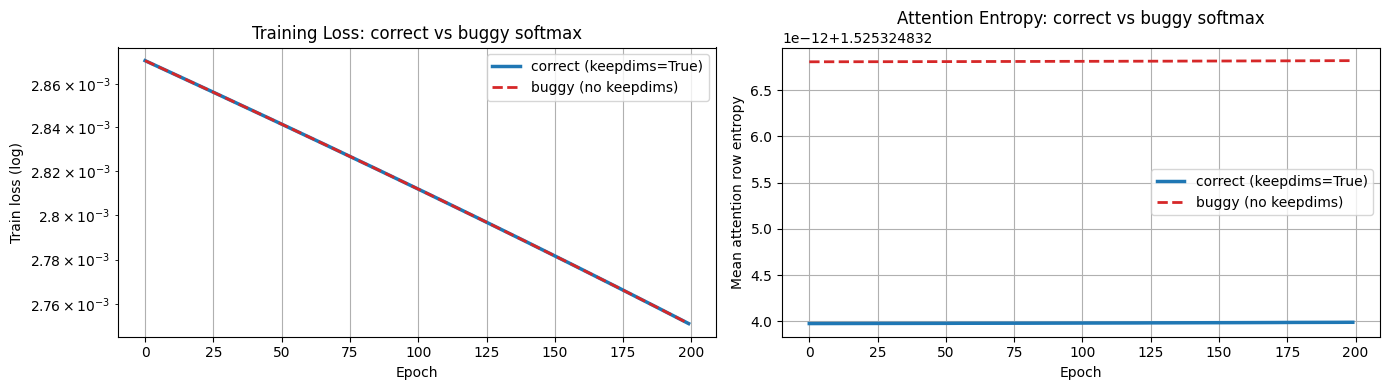

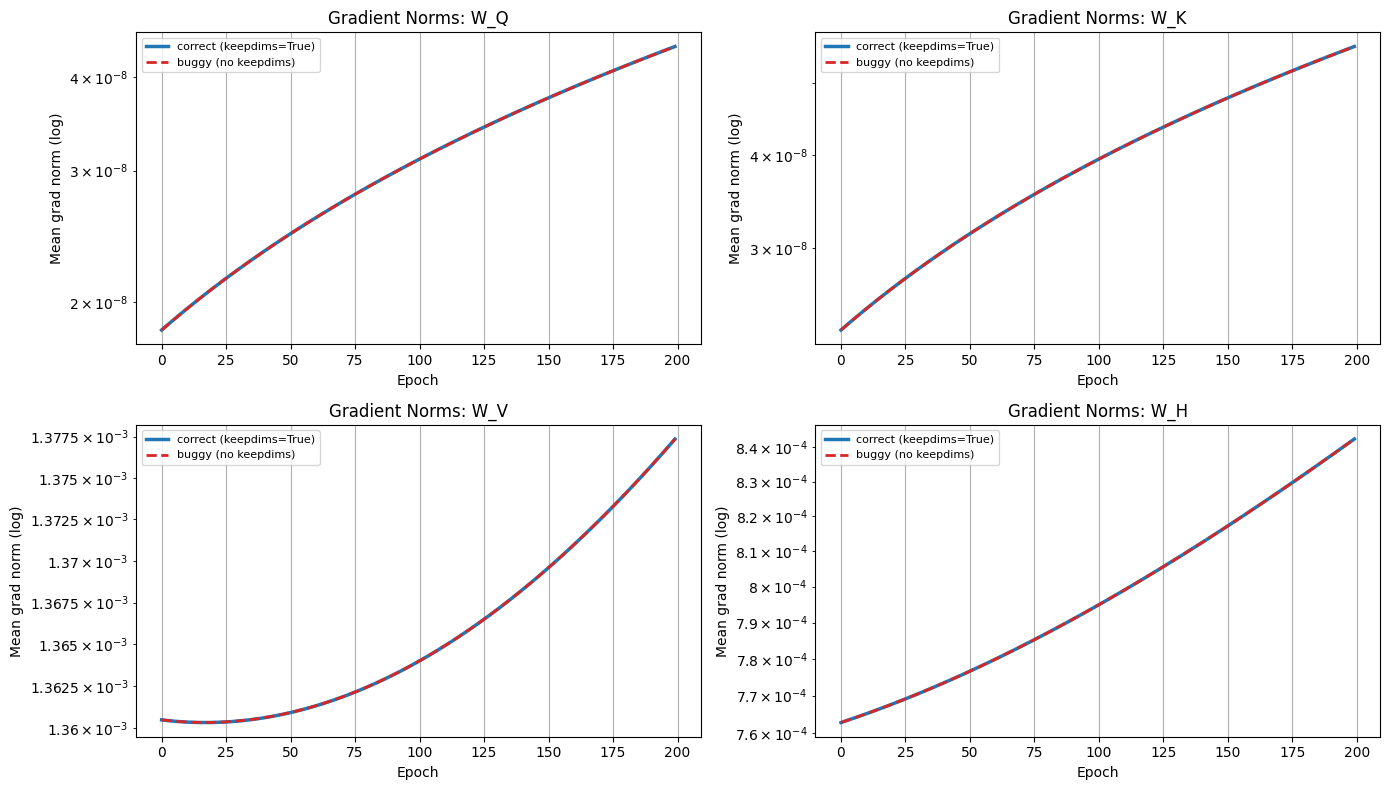


  correct (keepdims=True)  |  test MSE = 0.002677
scores (scaled dot-product):
[[-2.21219844e-06 -5.53049609e-06 -1.10609922e-06 -2.21219844e-06
  -9.95489296e-06  0.00000000e+00]
 [-5.53049609e-06 -1.38262402e-05 -2.76524804e-06 -5.53049609e-06
  -2.48872324e-05  0.00000000e+00]
 [-1.10609922e-06 -2.76524804e-06 -5.53049609e-07 -1.10609922e-06
  -4.97744648e-06  0.00000000e+00]
 [-2.21219844e-06 -5.53049609e-06 -1.10609922e-06 -2.21219844e-06
  -9.95489296e-06  0.00000000e+00]
 [-9.95489296e-06 -2.48872324e-05 -4.97744648e-06 -9.95489296e-06
  -4.47970183e-05  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]

A (attention weights, rows sum to 1):
[[0.16666688 0.16666633 0.16666707 0.16666688 0.16666559 0.16666725]
 [0.1666672  0.16666582 0.16666767 0.1666672  0.16666398 0.16666813]
 [0.16666677 0.1666665  0.16666687 0.16666677 0.16666613 0.16666696]
 [0.16666688 0.16666633 0.16666707 0.16666688 0.16666559 0.16666725

In [4]:
# Softmax sanity check: correct (keepdims=True) vs buggy (keepdims=False)
# 1) Broadcasting bug demo
# 2) Full training comparison: loss, gradient norms, attention entropy
# 3) Inspection of final attention + decoded predictions

# --- 1) Broadcasting bug demo ---
scores_demo = np.array([[1.0, 2.0, 3.0, 4.0],
                        [4.0, 3.0, 2.0, 1.0],
                        [0.0, 0.0, 0.0, 0.0],
                        [10., 10., 10., 10.]])

exp_scores = np.exp(scores_demo - np.max(scores_demo, axis=1, keepdims=True))
A_correct = row_softmax(scores_demo)
A_buggy   = row_softmax_buggy(scores_demo)

print("=== Broadcasting bug demo ===")
print("Exp scores:\n", exp_scores)
print("\nRow sums of exp_scores (keepdims=True):\n", np.sum(exp_scores, axis=1, keepdims=True))
print("Row sums of exp_scores (keepdims=False):\n", np.sum(exp_scores, axis=1))
print("\nCorrect softmax row sums:", np.round(A_correct.sum(axis=1), 6))
print("Buggy softmax row sums:  ", np.round(A_buggy.sum(axis=1), 6))
print("\nCorrect A:\n", np.round(A_correct, 4))
print("\nBuggy A:\n", np.round(A_buggy, 4))
print("\nCorrect A (first row):", np.round(A_correct[0], 4))
print("Buggy   A (first row):", np.round(A_buggy[0], 4))

# --- 2) Training comparison: correct vs buggy ---
# Use variable-length sequences so the broadcasting bug has a visible effect.
# With fixed dim=4, the correct and buggy lines overlap (the bug is subtle at n=4).
# Variable lengths (2–8) make the (n,n)/(n,) shape mismatch much more damaging.
d_model_demo = 8
init_scale_demo = 0.1
epochs_demo = 200
lr_demo = 1e-3
clip_demo = 1.0

rng_embed = np.random.default_rng(7)
W_embed_demo = init_scale_demo * rng_embed.standard_normal((1, d_model_demo))

# Variable-length dataset (same generator as the main training cell)
rng_demo = np.random.default_rng(99)
demo_dataset = []
for _ in range(300):
    L = int(rng_demo.integers(2, 9))  # lengths 2–8
    x_d, y_d = generate_argmax_sample(dim=L, value_range=(0, 10))
    demo_dataset.append((x_d, y_d))
demo_train = demo_dataset[:240]
demo_test  = demo_dataset[240:]

comparison = {}
for label, softmax_fn in [("correct (keepdims=True)", None),
                           ("buggy (no keepdims)", row_softmax_buggy)]:
    # Same initial weights for fair comparison
    rng_w = np.random.default_rng(7)
    wq = init_scale_demo * rng_w.standard_normal((d_model_demo, d_model_demo))
    wk = init_scale_demo * rng_w.standard_normal((d_model_demo, d_model_demo))
    wv = init_scale_demo * rng_w.standard_normal((d_model_demo, d_model_demo))
    wh = init_scale_demo * rng_w.standard_normal((d_model_demo, d_model_demo))

    loss_history = []
    grad_norm_history = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}
    entropy_history = []

    for epoch in range(epochs_demo):
        ep_losses = []
        ep_entropies = []
        ep_grad_norms = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

        for x_raw, y_raw in demo_train:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed_demo)
            wq, wk, wv, wh, loss, cache, grad_norms = attention_step(
                wq, wk, wv, wh, hidden, target,
                lr=lr_demo, clip=clip_demo, softmax_fn=softmax_fn
            )
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_entropies.append(attention_row_entropy(cache["A"]))
                for k in ep_grad_norms:
                    ep_grad_norms[k].append(grad_norms[k])

        loss_history.append(float(np.mean(ep_losses)) if ep_losses else float("nan"))
        entropy_history.append(float(np.mean(ep_entropies)) if ep_entropies else float("nan"))
        for k in grad_norm_history:
            grad_norm_history[k].append(float(np.mean(ep_grad_norms[k])) if ep_grad_norms[k] else float("nan"))

    # Test evaluation
    test_losses = []
    for x_raw, y_raw in demo_test:
        hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed_demo)
        pred = attention_forward(hidden, wq, wk, wv, wh, softmax_fn=softmax_fn)
        test_losses.append(mse(pred, target))

    comparison[label] = {
        "loss_history": loss_history,
        "grad_norm_history": grad_norm_history,
        "entropy_history": entropy_history,
        "test_mse": float(np.mean(test_losses)),
        "weights": (wq, wk, wv, wh),
    }
    print(f"\n{label}: final train loss = {loss_history[-1]:.6f}, test MSE = {float(np.mean(test_losses)):.6f}")

# --- 3) Plots: loss + entropy (distinct styles so both lines are clearly visible) ---
colors = {"correct (keepdims=True)": "tab:blue", "buggy (no keepdims)": "tab:red"}
styles = {"correct (keepdims=True)": "-",        "buggy (no keepdims)": "--"}
widths = {"correct (keepdims=True)": 2.5,        "buggy (no keepdims)": 2.0}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, res in comparison.items():
    axes[0].plot(res["loss_history"], styles[label], color=colors[label],
                 linewidth=widths[label], label=label)
    axes[1].plot(res["entropy_history"], styles[label], color=colors[label],
                 linewidth=widths[label], label=label)
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss (log)")
axes[0].set_title("Training Loss: correct vs buggy softmax")
axes[0].legend(); axes[0].grid(True)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean attention row entropy")
axes[1].set_title("Attention Entropy: correct vs buggy softmax")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

# Gradient norms (2x2, one per weight matrix)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
    ax = axes[idx // 2][idx % 2]
    for label, res in comparison.items():
        ax.plot(res["grad_norm_history"][wname], styles[label], color=colors[label],
                linewidth=widths[label], label=label)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Mean grad norm (log)")
    ax.set_title(f"Gradient Norms: {wname}")
    ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout()
plt.show()

# --- 4) Inspection: attention matrix + decoded predictions ---
for label, res in comparison.items():
    wq, wk, wv, wh = res["weights"]
    sfn = row_softmax_buggy if "buggy" in label else None

    print(f"\n{'='*55}")
    print(f"  {label}  |  test MSE = {res['test_mse']:.6f}")
    print(f"{'='*55}")

    x_t, y_t = demo_test[0]
    hidden_t, target_t = make_hidden_and_target(x_t, y_t, W_embed_demo)
    pred_t, cache_t = attention_forward(hidden_t, wq, wk, wv, wh,
                                         return_cache=True, softmax_fn=sfn)
    inspect_cache(cache_t)

    yhat = decode_embedding_to_scalar(pred_t, W_embed_demo)
    print(f"\nx:      {x_t}")
    print(f"target: {y_t}")
    print(f"pred:   {np.round(yhat, 3)}")
    print(f"A row sums: {np.round(cache_t['A'].sum(axis=1), 4)}")

## Why was the attention entropy constant?

**Problem:** The training comparison above uses `scale=10.0` in `make_hidden_and_target`, which divides all input values by 10 before embedding. This shrinks everything to the range ~0.0–0.9.

**Effect:** Small inputs → small activations → tiny gradients. The gradient norms printed above are ~1e-8. With `lr=1e-3`, the actual weight update per element is:

$$\Delta W \;=\; \text{lr} \times \nabla W \;\approx\; 10^{-3} \times 10^{-8} \;=\; 10^{-11}$$

That's essentially **zero movement**. The weights barely change, so the attention pattern (and its entropy) stays frozen at its random initialization.

**Fix:** In the cell below, we boost the signal:
- `scale=1.0` — inputs stay in the range 0–9 (no shrinking)
- `lr=1e-2` — 10× larger step size
- `clip=10.0` — allow larger gradient components

Now gradient norms become ~1e-1 instead of ~1e-8, and you can actually observe:
1. Weights changing (ΔW ≠ 0)
2. Loss decreasing
3. Entropy evolving (not stuck at initialization)

=== One-step weight-change check ===
loss: 0.3495631692411054
grad norms: {'W_Q': 1.5330341574402847e-05, 'W_K': 1.8663872710879292e-05, 'W_V': 0.13668454845602795, 'W_H': 0.11762837809418494}
ΔW_Q: 1.5330341574295476e-07
ΔW_K: 1.866387271075326e-07
ΔW_V: 0.0013668454845602832
ΔW_H: 0.001176283780941849
entropy(A) raw: 1.7917578667557803
entropy(A) normalized: 0.9999991056426366
correct (keepdims=True): final loss=0.013767, final H_norm=0.9988
buggy (no keepdims): final loss=0.011326, final H_norm=0.9960


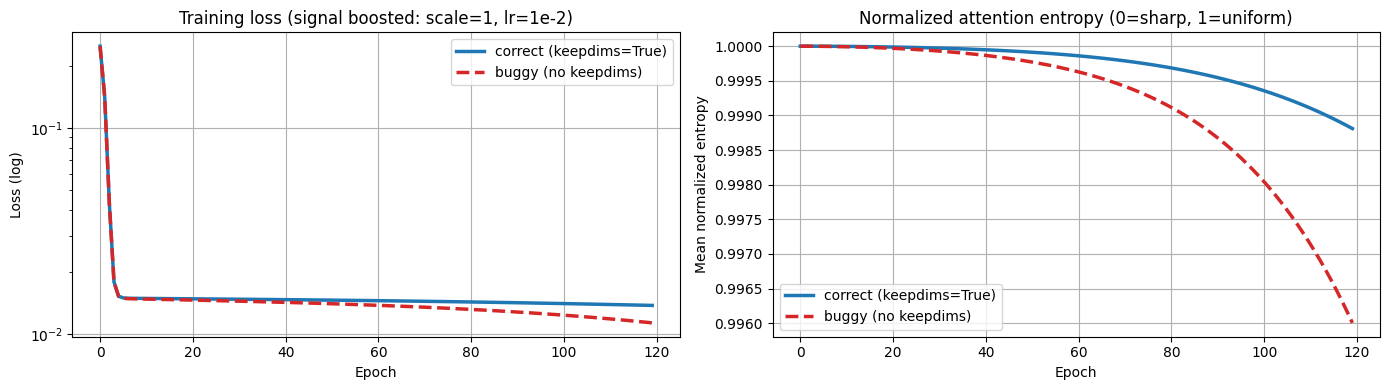

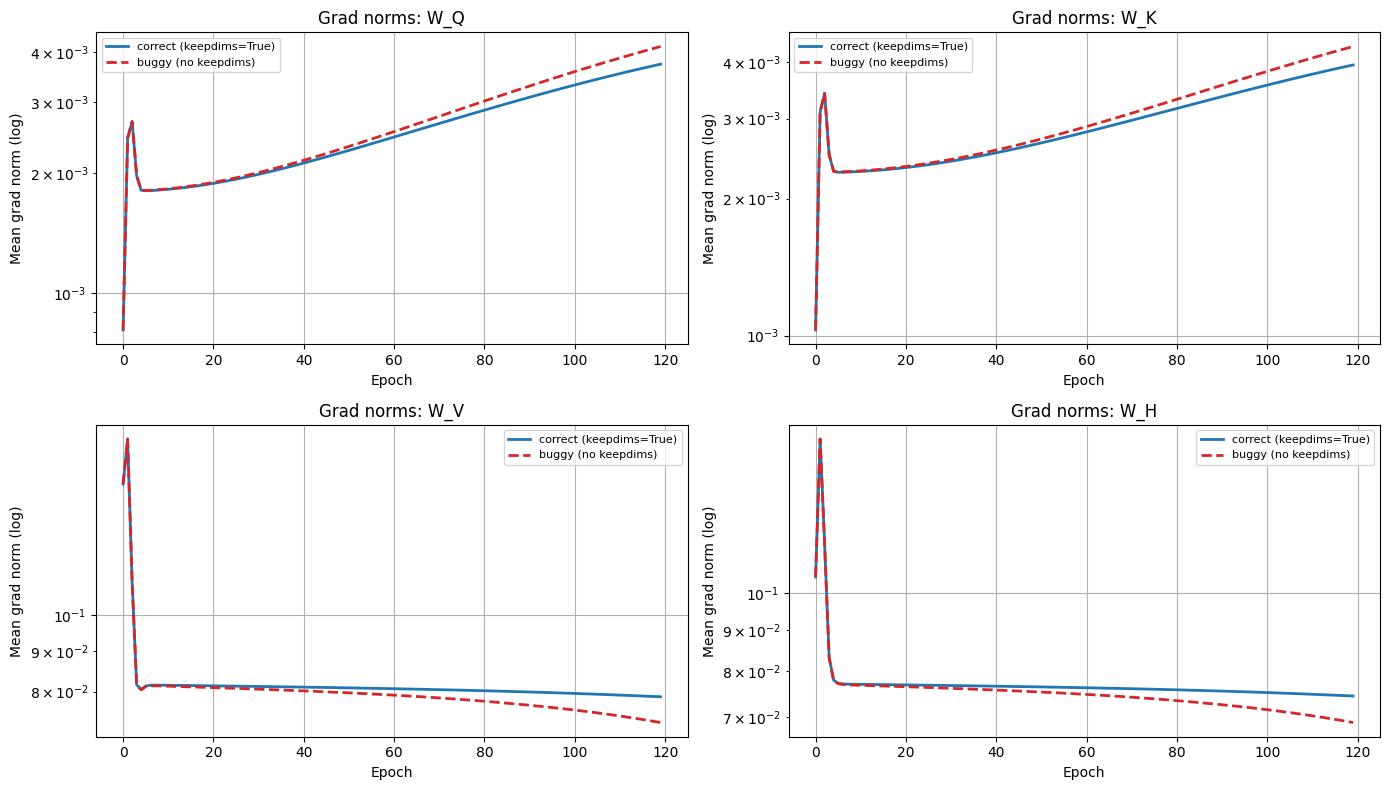

In [5]:
# Diagnostic + fix: verify weights change, and make entropy informative
# The original comparison had tiny grad norms (~1e-8) because scale=10.0 shrinks inputs.
# Fix: use scale=1.0, larger lr, larger clip => non-trivial gradient flow.

def attention_row_entropy_normalized(A: np.ndarray) -> float:
    """
    Normalized mean row entropy in [0,1].
    Also renormalizes rows so it's meaningful even if A isn't row-stochastic (buggy case).
    """
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    P = P / np.sum(P, axis=1, keepdims=True)  # re-normalize for buggy softmax
    H = -np.sum(P * np.log(P), axis=1)
    H_norm = H / (np.log(P.shape[1]) + eps)   # normalize by max entropy
    return float(np.mean(H_norm))


# ----------------------------
# 1) One-step check: do weights change at all?
# ----------------------------
rng_chk = np.random.default_rng(0)
d_model_chk = 8
init_scale_chk = 0.1

W_embed_chk = init_scale_chk * rng_chk.standard_normal((1, d_model_chk))
WQ0 = init_scale_chk * rng_chk.standard_normal((d_model_chk, d_model_chk))
WK0 = init_scale_chk * rng_chk.standard_normal((d_model_chk, d_model_chk))
WV0 = init_scale_chk * rng_chk.standard_normal((d_model_chk, d_model_chk))
WH0 = init_scale_chk * rng_chk.standard_normal((d_model_chk, d_model_chk))

x0, y0 = generate_argmax_sample(dim=6, value_range=(0, 10), seed=1)

# FIX: use scale=1.0 here to increase signal (avoid tiny gradients)
h0, t0 = make_hidden_and_target(x0, y0, W_embed_chk, scale=1.0)

WQ1, WK1, WV1, WH1, loss1, cache1, g1 = attention_step(
    WQ0, WK0, WV0, WH0, h0, t0,
    lr=1e-2, clip=10.0, softmax_fn=None
)

print("=== One-step weight-change check ===")
print("loss:", float(loss1))
print("grad norms:", g1)
print("ΔW_Q:", float(np.linalg.norm(WQ1 - WQ0)))
print("ΔW_K:", float(np.linalg.norm(WK1 - WK0)))
print("ΔW_V:", float(np.linalg.norm(WV1 - WV0)))
print("ΔW_H:", float(np.linalg.norm(WH1 - WH0)))
print("entropy(A) raw:", attention_row_entropy(cache1["A"]))
print("entropy(A) normalized:", attention_row_entropy_normalized(cache1["A"]))


# ----------------------------
# 2) Short training run where entropy can actually move
# ----------------------------
rng_demo2 = np.random.default_rng(99)
demo_dataset2 = []
for _ in range(300):
    L = int(rng_demo2.integers(2, 9))  # lengths 2–8
    xd, yd = generate_argmax_sample(dim=L, value_range=(0, 10))
    demo_dataset2.append((xd, yd))
demo_train2 = demo_dataset2[:240]
demo_test2  = demo_dataset2[240:]

d_model_demo2 = 8
init_scale_demo2 = 0.1
epochs_demo2 = 120

# FIX: larger lr + larger clip + scale=1.0 => non-trivial updates
lr_demo2 = 1e-2
clip_demo2 = 10.0
scale_demo2 = 1.0

rng_embed2 = np.random.default_rng(7)
W_embed_demo2 = init_scale_demo2 * rng_embed2.standard_normal((1, d_model_demo2))

comparison2 = {}
for label, softmax_fn in [("correct (keepdims=True)", None),
                          ("buggy (no keepdims)", row_softmax_buggy)]:

    rng_w2 = np.random.default_rng(7)
    wq = init_scale_demo2 * rng_w2.standard_normal((d_model_demo2, d_model_demo2))
    wk = init_scale_demo2 * rng_w2.standard_normal((d_model_demo2, d_model_demo2))
    wv = init_scale_demo2 * rng_w2.standard_normal((d_model_demo2, d_model_demo2))
    wh = init_scale_demo2 * rng_w2.standard_normal((d_model_demo2, d_model_demo2))

    loss_hist = []
    ent_norm_hist = []
    g_hist = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

    for _ in range(epochs_demo2):
        ep_losses = []
        ep_entn = []
        ep_g = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

        for x_raw, y_raw in demo_train2:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed_demo2, scale=scale_demo2)
            wq, wk, wv, wh, loss, cache, grad_norms = attention_step(
                wq, wk, wv, wh, hidden, target,
                lr=lr_demo2, clip=clip_demo2, softmax_fn=softmax_fn
            )
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_entn.append(attention_row_entropy_normalized(cache["A"]))
                for k in ep_g:
                    ep_g[k].append(grad_norms[k])

        loss_hist.append(float(np.mean(ep_losses)) if ep_losses else float("nan"))
        ent_norm_hist.append(float(np.mean(ep_entn)) if ep_entn else float("nan"))
        for k in g_hist:
            g_hist[k].append(float(np.mean(ep_g[k])) if ep_g[k] else float("nan"))

    comparison2[label] = {"loss": loss_hist, "ent_norm": ent_norm_hist, "g": g_hist}
    print(f"{label}: final loss={loss_hist[-1]:.6f}, final H_norm={ent_norm_hist[-1]:.4f}")

colors2 = {"correct (keepdims=True)": "tab:blue", "buggy (no keepdims)": "tab:red"}
styles2 = {"correct (keepdims=True)": "-", "buggy (no keepdims)": "--"}

# Loss + normalized entropy (now both should be visible)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for label, res in comparison2.items():
    ax[0].plot(res["loss"], styles2[label], color=colors2[label], linewidth=2.5, label=label)
    ax[1].plot(res["ent_norm"], styles2[label], color=colors2[label], linewidth=2.5, label=label)
ax[0].set_yscale("log")
ax[0].set_title("Training loss (signal boosted: scale=1, lr=1e-2)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss (log)"); ax[0].grid(True); ax[0].legend()
ax[1].set_title("Normalized attention entropy (0=sharp, 1=uniform)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Mean normalized entropy"); ax[1].grid(True); ax[1].legend()
plt.tight_layout()
plt.show()

# Gradient norms
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
    a = axes[idx // 2][idx % 2]
    for label, res in comparison2.items():
        a.plot(res["g"][wname], styles2[label], color=colors2[label], linewidth=2.0, label=label)
    a.set_yscale("log")
    a.set_title(f"Grad norms: {wname}")
    a.set_xlabel("Epoch"); a.set_ylabel("Mean grad norm (log)"); a.grid(True); a.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Dataset + Instrumented Training
This cell builds the variable-length dataset, initializes weights, trains via SGD, and produces loss/gradient/entropy plots.
All functions are defined in the shared cell above.

Dataset size: 400 | train: 320 | test: 80 | lengths: [2,8]
epoch   50 | train loss 0.006172 | mean entropy(A) 1.4872
probe x: [7 7 8 1 5 5]
probe y: [8 8 8 8 8 8]
probe yhat: [0.2 0.2 0.2 0.2 0.2 0.2]
probe embedded MSE: 0.006581055205733516
probe attention A (top-left):
[[0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1666 0.1666 0.1666 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]]
-
epoch  100 | train loss 0.005895 | mean entropy(A) 1.4872
probe x: [7 7 8 1 5 5]
probe y: [8 8 8 8 8 8]
probe yhat: [0.405 0.405 0.405 0.405 0.405 0.405]
probe embedded MSE: 0.006241975117428698
probe attention A (top-left):
[[0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1666 0.1666 0.1666 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
 [0.1667 0.1667 0.1666 0.1667 0.1667 0.1667]
 [0.1

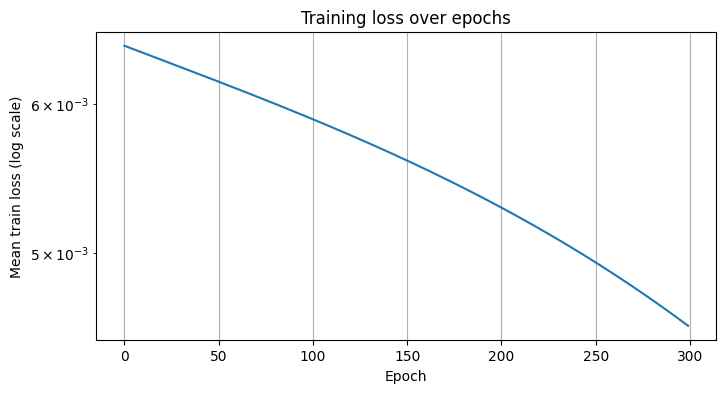

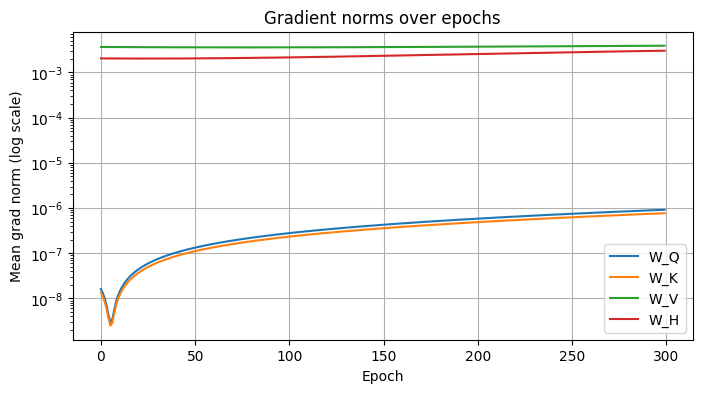

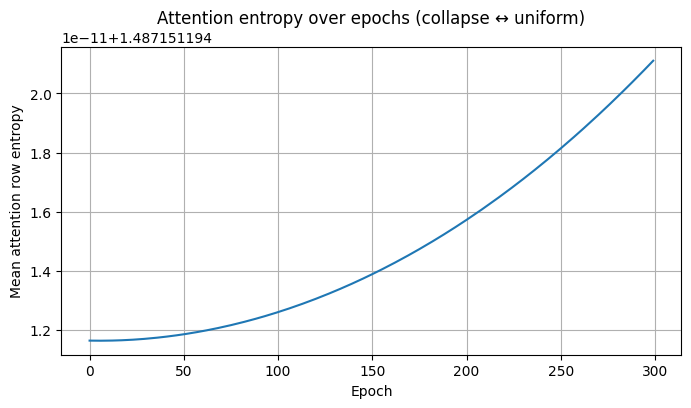


--- Final held-out test inspection ---
x_test: [7 7 8 1 5 5]
y_test: [8 8 8 8 8 8]
scores (scaled dot-product):
[[-4.19242227e-04 -4.19242227e-04 -4.79133974e-04 -5.98917468e-05
  -2.99458734e-04 -2.99458734e-04]
 [-4.19242227e-04 -4.19242227e-04 -4.79133974e-04 -5.98917468e-05
  -2.99458734e-04 -2.99458734e-04]
 [-4.79133974e-04 -4.79133974e-04 -5.47581685e-04 -6.84477106e-05
  -3.42238553e-04 -3.42238553e-04]
 [-5.98917468e-05 -5.98917468e-05 -6.84477106e-05 -8.55596382e-06
  -4.27798191e-05 -4.27798191e-05]
 [-2.99458734e-04 -2.99458734e-04 -3.42238553e-04 -4.27798191e-05
  -2.13899096e-04 -2.13899096e-04]
 [-2.99458734e-04 -2.99458734e-04 -3.42238553e-04 -4.27798191e-05
  -2.13899096e-04 -2.13899096e-04]]

A (attention weights, rows sum to 1):
[[0.16665169 0.16665169 0.16664171 0.16671159 0.16667166 0.16667166]
 [0.16665169 0.16665169 0.16664171 0.16671159 0.16667166 0.16667166]
 [0.16664955 0.16664955 0.16663815 0.16671801 0.16667237 0.16667237]
 [0.16666453 0.16666453 0.1666631 

In [7]:
# ----------------------------
# Dataset: variable-length sequences (no batching)
# ----------------------------
N = 400
min_len = 2
max_len = 8
value_range = (0, 10)

rng_data = np.random.default_rng(123)
dataset = []
for _ in range(N):
    L = int(rng_data.integers(min_len, max_len + 1))
    x, y = generate_argmax_sample(dim=L, value_range=value_range)
    dataset.append((x, y))

train_frac = 0.8
train_N = int(N * train_frac)
test_set = dataset[train_N:]
train_set = dataset[:train_N]
print(f"Dataset size: {N} | train: {len(train_set)} | test: {len(test_set)} | lengths: [{min_len},{max_len}]")

# ----------------------------
# Initialize ONE set of weights (reused across all training samples)
# ----------------------------
d_model = 8  # <= 16 (assignment requirement)

init_scale = 0.1
# It's the standard deviation multiplier for random weight initialization:
# This keeps initial weights small so gradients don't explode at the start of training.

rng = np.random.default_rng(0)
W_Q = init_scale * rng.standard_normal((d_model, d_model))
W_K = init_scale * rng.standard_normal((d_model, d_model))
W_V = init_scale * rng.standard_normal((d_model, d_model))
W_H = init_scale * rng.standard_normal((d_model, d_model))
W_embed = init_scale * rng.standard_normal((1, d_model))  # map scalar -> d_model

# ----------------------------
# Instrumentation probes (fixed train + test samples)
# ----------------------------
probe_train = train_set[0]
probe_test = test_set[0]

# ----------------------------
# Train (SGD over train_set; still no batching)
# ----------------------------
epochs = 300
# Number of passes through the entire training set. More epochs can lead to better convergence but also risk overfitting.

lr = 1e-3
# Learning rate: controls the step size of weight updates. Too high can cause divergence; too low can lead to slow convergence.
# 1e-3 is a common default for Adam, but for vanilla SGD it may require tuning based on the loss landscape.

clip = 1.0
# gradient clipping threshold. Every gradient element is clamped to the range [-1.0, 1.0]
# before updating weights. This prevents any single huge gradient
# from blowing up the weights (exploding gradients). Without it, one bad sample could destabilize the entire model.

log_every = 50
# print diagnostic output every 50 epochs. That's where the probe sample's prediction,
# MSE, and attention matrix get printed. With 300 epochs, you get 6 log checkpoints (at epochs 50, 100, 150, 200, 250, 300).

loss_history = []
# Stores the mean training loss for each epoch. This is useful for monitoring convergence: you should see it generally decrease over time.

grad_norm_history = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}
# If norms are very small (e.g. W_Q and W_K norms near zero) → those weights are barely updating,
# meaning attention isn't learning any structure. This is the "gradient starvation" problem mentioned in Experiment B.
# If norms are very large or spiking → gradients are exploding, training is unstable (that's why clip exists).
# If norms are shrinking over time → the model may be converging (good) or collapsing (bad — check entropy too).

entropy_history = []
# tracks the mean attention entropy per epoch — how spread out the attention weights are across positions.

probe_pred_history = []

for epoch in range(epochs):
    epoch_losses = []
    epoch_grad_norms = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}
    epoch_entropies = []

    for x_raw, y_raw in train_set:
        hidden_layer, target = make_hidden_and_target(x_raw, y_raw, W_embed)
        W_Q, W_K, W_V, W_H, loss, cache, grad_norms = attention_step(
            W_Q, W_K, W_V, W_H, hidden_layer, target, lr=lr, clip=clip
        )
        if np.isfinite(loss):
            epoch_losses.append(loss)
            for k in epoch_grad_norms:
                epoch_grad_norms[k].append(grad_norms[k])
            epoch_entropies.append(attention_row_entropy(cache["A"]))

    mean_loss = float(np.mean(epoch_losses)) if epoch_losses else float("nan")
    loss_history.append(mean_loss)
    for k in grad_norm_history:
        grad_norm_history[k].append(float(np.mean(epoch_grad_norms[k])) if epoch_grad_norms[k] else float("nan"))
    entropy_history.append(float(np.mean(epoch_entropies)) if epoch_entropies else float("nan"))

    # Log a forward pass on a fixed probe to monitor behavior (collapse/divergence)
    if (epoch + 1) % log_every == 0:
        x_p, y_p = probe_test
        hidden_p, target_p = make_hidden_and_target(x_p, y_p, W_embed)
        pred_p, cache_p = attention_forward(hidden_p, W_Q, W_K, W_V, W_H, return_cache=True)
        yhat_p = decode_embedding_to_scalar(pred_p, W_embed)
        probe_pred_history.append(yhat_p.copy())
        print(f"epoch {epoch+1:4d} | train loss {mean_loss:.6f} | mean entropy(A) {entropy_history[-1]:.4f}")
        print("probe x:", x_p)
        print("probe y:", y_p)
        print("probe yhat:", np.round(yhat_p, 3))
        print("probe embedded MSE:", float(mse(pred_p, target_p)))
        print("probe attention A (top-left):")
        n = min(6, cache_p["A"].shape[0])
        print(np.round(cache_p["A"][:n, :n], 4))
        print("-")

# ----------------------------
# Plots: loss + gradient norms + attention entropy
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Mean train loss (log scale)")
plt.title("Training loss over epochs")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for k, vals in grad_norm_history.items():
    plt.plot(vals, label=k)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Mean grad norm (log scale)")
plt.title("Gradient norms over epochs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(entropy_history)
plt.xlabel("Epoch")
plt.ylabel("Mean attention row entropy")
plt.title("Attention entropy over epochs (collapse ↔ uniform)")
plt.grid(True)
plt.show()

# ----------------------------
# Evaluate: forward pass on held-out test sample using TRAINED weights
# ----------------------------
x_test, y_test = probe_test
hidden_test, target_test = make_hidden_and_target(x_test, y_test, W_embed)
pred_test, cache_test = attention_forward(hidden_test, W_Q, W_K, W_V, W_H, return_cache=True)

print("\n--- Final held-out test inspection ---")
print("x_test:", x_test)
print("y_test:", y_test)
inspect_cache(cache_test, max_rows=8)

print("\nEmbedded pred (first row):  ", np.round(pred_test[0], 6))
print("Embedded target (first row):", np.round(target_test[0], 6))

yhat_test = decode_embedding_to_scalar(pred_test, W_embed)
y_from_embed = decode_embedding_to_scalar(target_test, W_embed)
print("\nDecoded prediction (per position):", np.round(yhat_test, 3))
print("Decoded target from embedding:     ", np.round(y_from_embed, 3))
print("Target (original y_test):         ", y_test)
print("\nTest MSE (embedded):", float(mse(pred_test, target_test)))

# Next steps (do these for the assignment)
## 1) Add one controlled fix experiment
Pick **ONE** of the two experiments below, run it, and record: hypothesis → what you changed → plots/metrics → interpretation.

**Experiment A (temperature / sharpening):** Multiply attention scores by $\alpha$ before softmax (try `alpha ∈ {0.5, 1.0, 2.0, 4.0}`).
- Hypothesis: larger $\alpha$ makes attention less uniform (lower entropy) and increases Q/K gradient signal.

**Experiment B (separate learning rates):** Use `lr_qk` smaller than `lr_vh` (or vice versa).
- Hypothesis: Q/K gradients can be “starved”; changing step sizes may let attention structure emerge.

## 2) Add a small test evaluation
After training, compute mean test MSE over e.g. 50 test samples (no batching; loop).
Also decode predictions back to scalar space for 2–3 examples and print them.

## 3) Write your report section headings
Use: Background → Failure analysis → Fixes → Experiments → Results → Interpretation → Limitations.

## Experiment A — temperature scaling ($\alpha$ on attention scores)
Run this after the training cell. It will re-train fresh weights for a few $\alpha$ values and compare final train loss, mean test MSE, and attention entropy.

Alpha experiment results:
{'alpha': 0.5, 'train_mse': 0.006169671135405033, 'test_mse': 0.006033380121954908, 'test_entropy': 1.5245467425357344}
{'alpha': 1.0, 'train_mse': 0.006211817353404781, 'test_mse': 0.006074940121303225, 'test_entropy': 1.524546714215673}
{'alpha': 2.0, 'train_mse': 0.006636674574395781, 'test_mse': 0.006492662689023325, 'test_entropy': 1.5245467075738626}
{'alpha': 4.0, 'train_mse': 0.006366757318667772, 'test_mse': 0.006227098664003858, 'test_entropy': 1.5245467440182439}


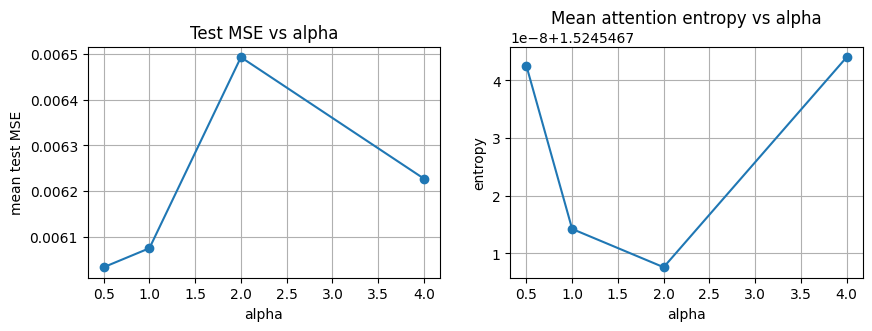

In [11]:
# Run alpha sweep (functions defined in shared cell above)
results = run_alpha_experiment(alphas=(0.5, 1.0, 2.0, 4.0), epochs=80, lr=1e-3, clip=1.0, seed=0)
print("Alpha experiment results:")
for r in results:
    print(r)

# Quick plot (alpha vs test_mse)
alphas = [r["alpha"] for r in results]
test_mse = [r["test_mse"] for r in results]
ent = [r["test_entropy"] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(alphas, test_mse, marker='o')
ax[0].set_title("Test MSE vs alpha")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("mean test MSE")
ax[0].grid(True)

ax[1].plot(alphas, ent, marker='o')
ax[1].set_title("Mean attention entropy vs alpha")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("entropy")
ax[1].grid(True)
plt.show()

In [9]:
# Template: quick test-set evaluation (no batching)

# Assumes your training cell created: train_set, test_set, W_embed, W_Q, W_K, W_V, W_H

def eval_mean_test_mse(test_set, W_embed, W_Q, W_K, W_V, W_H):
    losses = []
    for x_raw, y_raw in test_set:
        hidden_test, target_test = make_hidden_and_target(x_raw, y_raw, W_embed)
        pred_test = attention_forward(hidden_test, W_Q, W_K, W_V, W_H)
        losses.append(mse(pred_test, target_test))
    return float(np.mean(losses))

mean_test = eval_mean_test_mse(test_set, W_embed, W_Q, W_K, W_V, W_H)
print("Mean test MSE (embedded space):", mean_test)

# Decode a couple examples to scalar space for interpretability
for j in range(min(3, len(test_set))):
    x_raw, y_raw = test_set[j]
    hidden_test, target_test = make_hidden_and_target(x_raw, y_raw, W_embed)
    pred_test, cache_test = attention_forward(hidden_test, W_Q, W_K, W_V, W_H, return_cache=True)
    yhat = decode_embedding_to_scalar(pred_test, W_embed)
    print(f"\nExample {j}")
    print("x:", x_raw)
    print("target (scalar):", y_raw)
    print("pred   (scalar):", np.round(yhat, 3))
    print("attention row-sums:", np.round(cache_test['A'].sum(axis=1), 6))

Mean test MSE (embedded space): 0.004618729496448934

Example 0
x: [7 7 8 1 5 5]
target (scalar): [8 8 8 8 8 8]
pred   (scalar): [1.465 1.465 1.465 1.465 1.465 1.465]
attention row-sums: [1. 1. 1. 1. 1. 1.]

Example 1
x: [9 1]
target (scalar): [9 9]
pred   (scalar): [1.332 1.332]
attention row-sums: [1. 1.]

Example 2
x: [5 6 3 1 6 3 5]
target (scalar): [6 6 6 6 6 6 6]
pred   (scalar): [1.104 1.104 1.104 1.104 1.104 1.104 1.104]
attention row-sums: [1. 1. 1. 1. 1. 1. 1.]



α=1.0, lr=1e-03 → train_loss=0.004591, test_mse=0.004869, entropy=1.5245
  ex0: x=[2 7 9 6 9 6]  max=9  mean=6.5  pred=[1.72 1.72 1.72 1.72 1.72 1.72]  → FAR FROM BOTH
  ex1: x=[0 2]  max=2  mean=1.0  pred=[0.27 0.27]  → FAR FROM BOTH
  ex2: x=[1 4 6 3 8 7 5]  max=8  mean=4.9  pred=[1.29 1.29 1.29 1.29 1.29 1.29 1.29]  → FAR FROM BOTH

α=2.0, lr=1e-03 → train_loss=0.004591, test_mse=0.004870, entropy=1.5245
  ex0: x=[2 7 9 6 9 6]  max=9  mean=6.5  pred=[1.72 1.72 1.72 1.72 1.72 1.72]  → FAR FROM BOTH
  ex1: x=[0 2]  max=2  mean=1.0  pred=[0.27 0.27]  → FAR FROM BOTH
  ex2: x=[1 4 6 3 8 7 5]  max=8  mean=4.9  pred=[1.29 1.29 1.29 1.29 1.29 1.29 1.29]  → FAR FROM BOTH

α=2.0, qk=5e-03, vh=1e-03 → train_loss=0.004591, test_mse=0.004870, entropy=1.5245
  ex0: x=[2 7 9 6 9 6]  max=9  mean=6.5  pred=[1.72 1.72 1.72 1.72 1.72 1.72]  → FAR FROM BOTH
  ex1: x=[0 2]  max=2  mean=1.0  pred=[0.27 0.27]  → FAR FROM BOTH
  ex2: x=[1 4 6 3 8 7 5]  max=8  mean=4.9  pred=[1.29 1.29 1.29 1.29 1.29 1.29

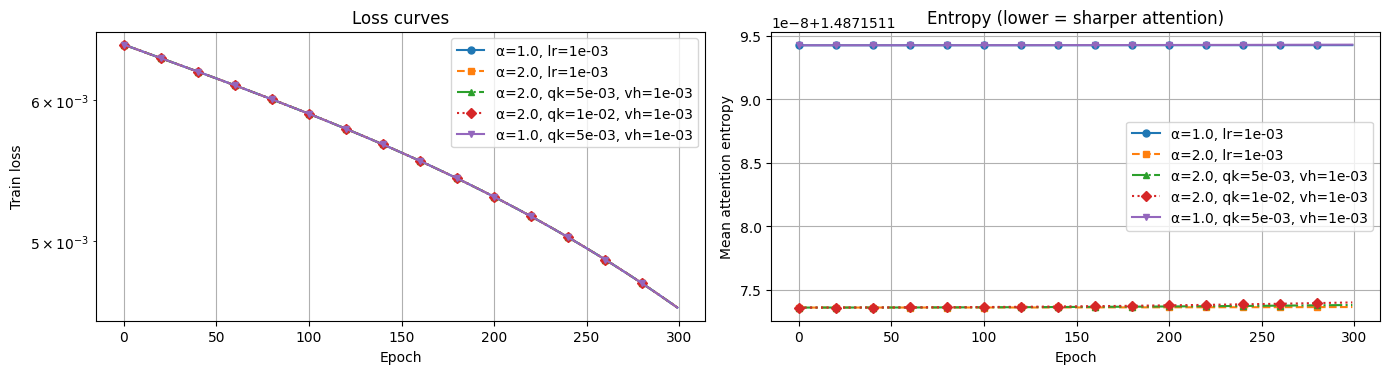

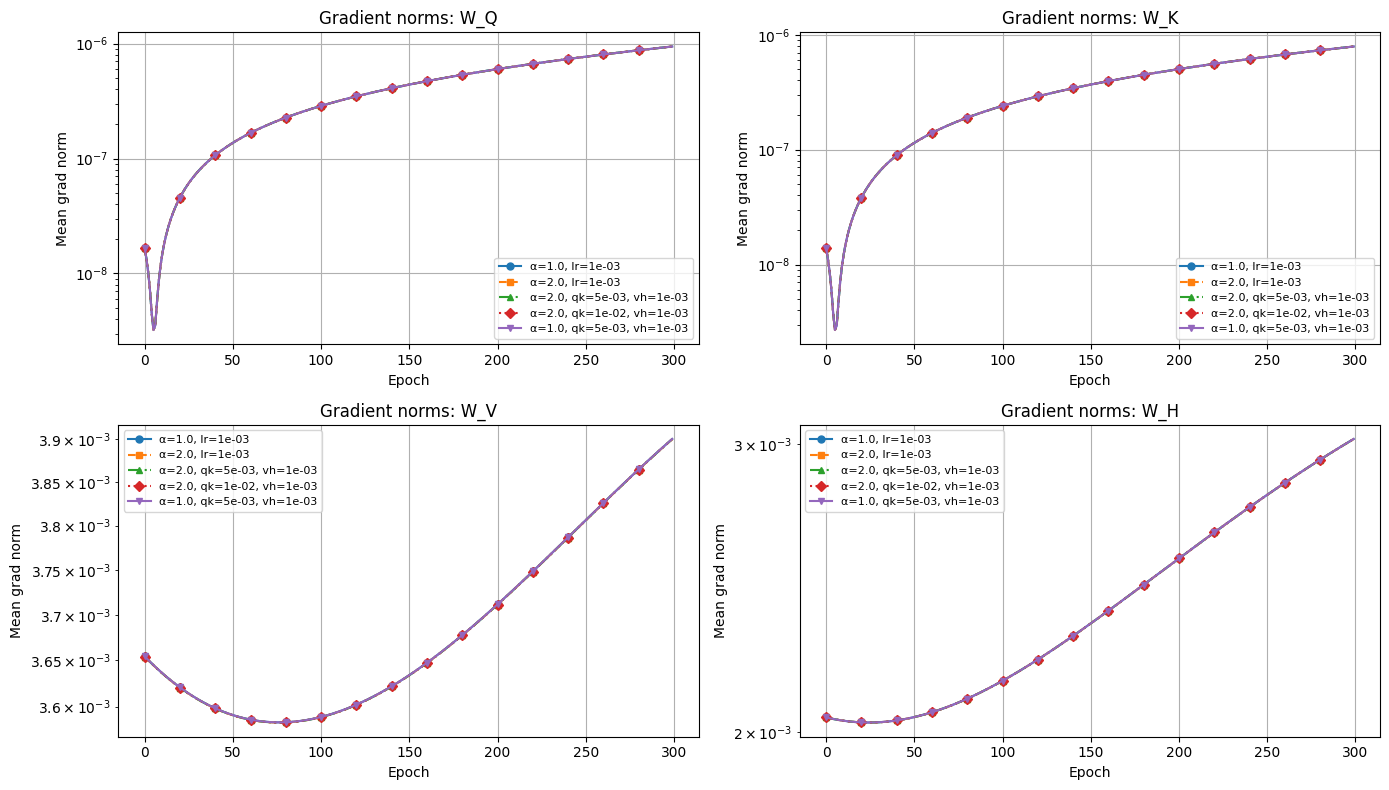

In [ ]:
# --- Run a grid of experiments (A + B) ---
configs = [
    # Experiment A: temperature scaling
    {"alpha": 1.0, "epochs": 300, "lr": 1e-3},
    {"alpha": 2.0, "epochs": 300, "lr": 1e-3},
    # Experiment B: split learning rates (boost Q/K to fight gradient starvation)
    {"alpha": 2.0, "epochs": 300, "lr_qk": 5e-3, "lr_vh": 1e-3},
    {"alpha": 2.0, "epochs": 300, "lr_qk": 1e-2, "lr_vh": 1e-3},
    {"alpha": 1.0, "epochs": 300, "lr_qk": 5e-3, "lr_vh": 1e-3},
]

results = run_and_print(configs, seed=0)
plot_results(results)

## Experiment A — Temperature Scaling (uniform lr)


α=1.0, lr=1e-03 → train_loss=0.004574, test_mse=0.004635, entropy=1.5245
  ex0: x=[7 7 8 1 5 5]  max=8  mean=5.5  pred=[1.47 1.47 1.47 1.47 1.47 1.47]  → FAR FROM BOTH
  ex1: x=[9 1]  max=9  mean=5.0  pred=[1.33 1.33]  → FAR FROM BOTH
  ex2: x=[5 6 3 1 6 3 5]  max=6  mean=4.1  pred=[1.1 1.1 1.1 1.1 1.1 1.1 1.1]  → FAR FROM BOTH

α=2.0, lr=1e-03 → train_loss=0.004574, test_mse=0.004635, entropy=1.5245
  ex0: x=[7 7 8 1 5 5]  max=8  mean=5.5  pred=[1.46 1.46 1.46 1.47 1.47 1.47]  → FAR FROM BOTH
  ex1: x=[9 1]  max=9  mean=5.0  pred=[1.33 1.33]  → FAR FROM BOTH
  ex2: x=[5 6 3 1 6 3 5]  max=6  mean=4.1  pred=[1.1 1.1 1.1 1.1 1.1 1.1 1.1]  → FAR FROM BOTH

α=2.0, lr=5e-04 → train_loss=0.005603, test_mse=0.005643, entropy=1.5245
  ex0: x=[7 7 8 1 5 5]  max=8  mean=5.5  pred=[0.62 0.62 0.62 0.63 0.63 0.63]  → FAR FROM BOTH
  ex1: x=[9 1]  max=9  mean=5.0  pred=[0.57 0.57]  → FAR FROM BOTH
  ex2: x=[5 6 3 1 6 3 5]  max=6  mean=4.1  pred=[0.47 0.47 0.47 0.47 0.47 0.47 0.47]  → FAR FROM BOTH


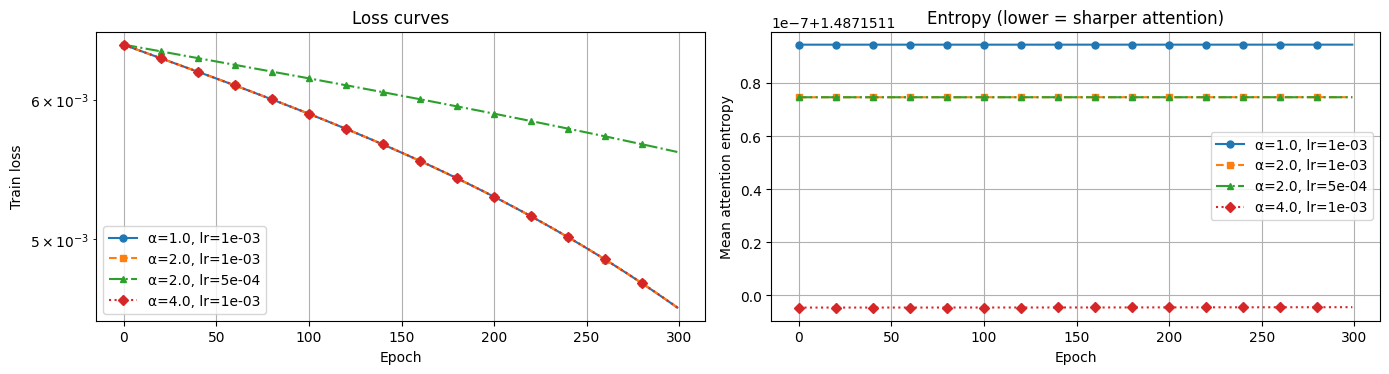

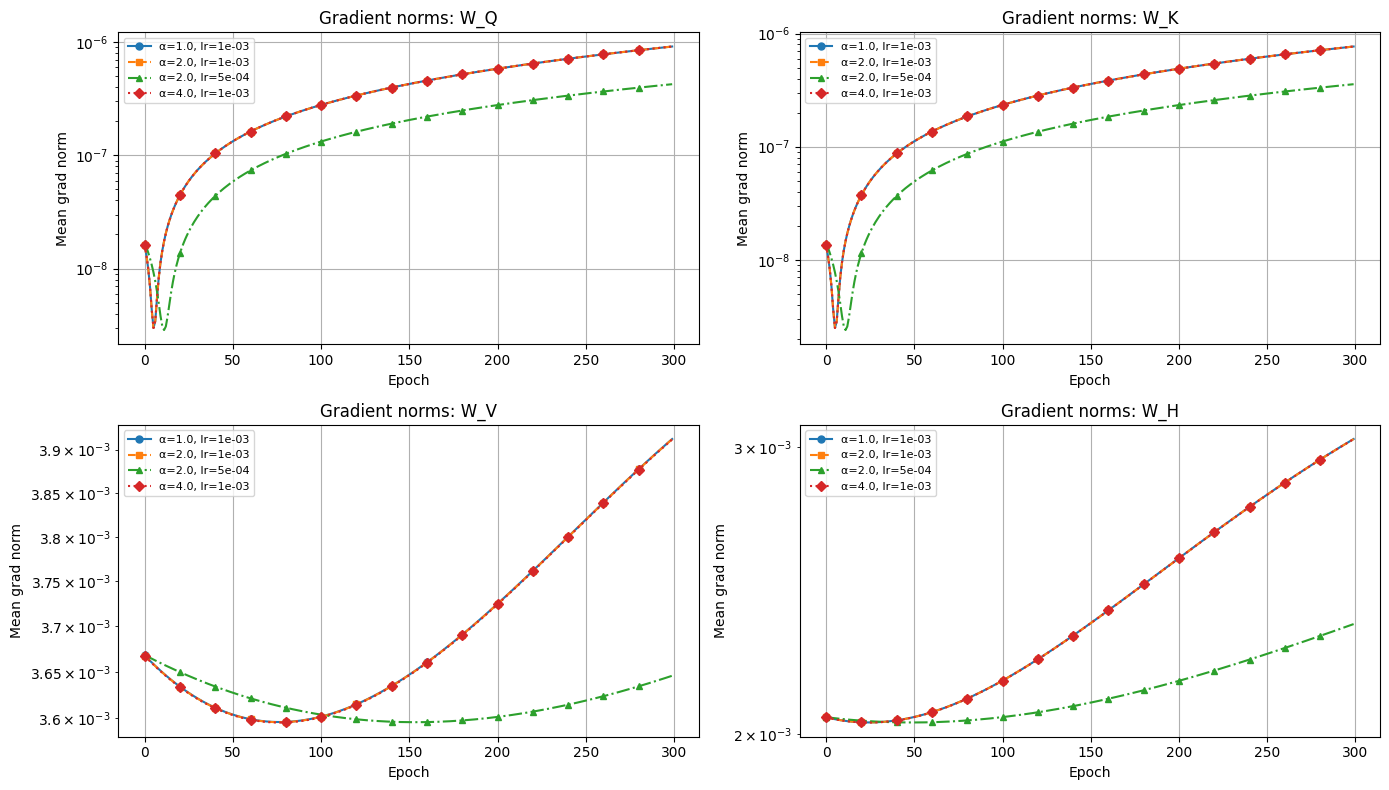

In [10]:
# Experiment A configs — same lr for all weights, vary alpha
configs_A = [
    {"alpha": 1.0, "epochs": 300, "lr": 1e-3, "clip": 1.0},
    {"alpha": 2.0, "epochs": 300, "lr": 1e-3, "clip": 1.0},
    {"alpha": 2.0, "epochs": 300, "lr": 5e-4, "clip": 1.0},
    {"alpha": 4.0, "epochs": 300, "lr": 1e-3, "clip": 1.0},
]

results_A = run_and_print(configs_A)
plot_results(results_A)

## Experiment B — Split Learning Rates (Q/K vs V/H)


α=2.0, qk=5e-03, vh=1e-03 → train_loss=0.004596, test_mse=0.004573, entropy=1.5245
  ex0: x=[7 4 8 3 3 1]  max=8  mean=4.3  pred=[1.08 1.08 1.08 1.08 1.08 1.08]  → FAR FROM BOTH
  ex1: x=[7 5]  max=7  mean=6.0  pred=[1.49 1.49]  → FAR FROM BOTH
  ex2: x=[5 7 7 3 2 1 2]  max=7  mean=3.9  pred=[0.96 0.96 0.96 0.96 0.96 0.96 0.96]  → FAR FROM BOTH

α=2.0, qk=1e-02, vh=1e-03 → train_loss=0.004596, test_mse=0.004573, entropy=1.5245
  ex0: x=[7 4 8 3 3 1]  max=8  mean=4.3  pred=[1.08 1.08 1.08 1.08 1.08 1.08]  → FAR FROM BOTH
  ex1: x=[7 5]  max=7  mean=6.0  pred=[1.49 1.49]  → FAR FROM BOTH
  ex2: x=[5 7 7 3 2 1 2]  max=7  mean=3.9  pred=[0.96 0.96 0.96 0.96 0.96 0.96 0.96]  → FAR FROM BOTH

α=1.0, qk=5e-03, vh=1e-03 → train_loss=0.004596, test_mse=0.004572, entropy=1.5245
  ex0: x=[7 4 8 3 3 1]  max=8  mean=4.3  pred=[1.08 1.08 1.08 1.08 1.08 1.08]  → FAR FROM BOTH
  ex1: x=[7 5]  max=7  mean=6.0  pred=[1.49 1.49]  → FAR FROM BOTH
  ex2: x=[5 7 7 3 2 1 2]  max=7  mean=3.9  pred=[0.96 0.96

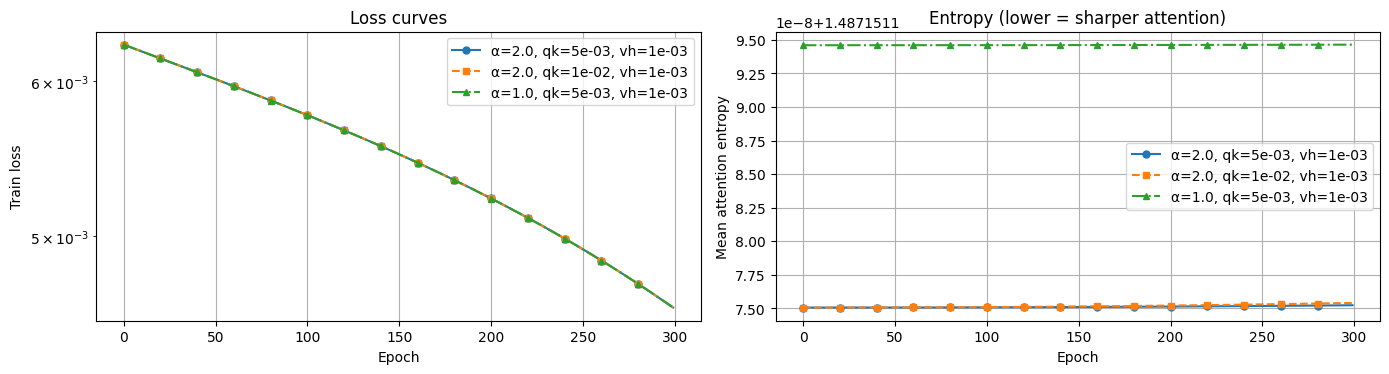

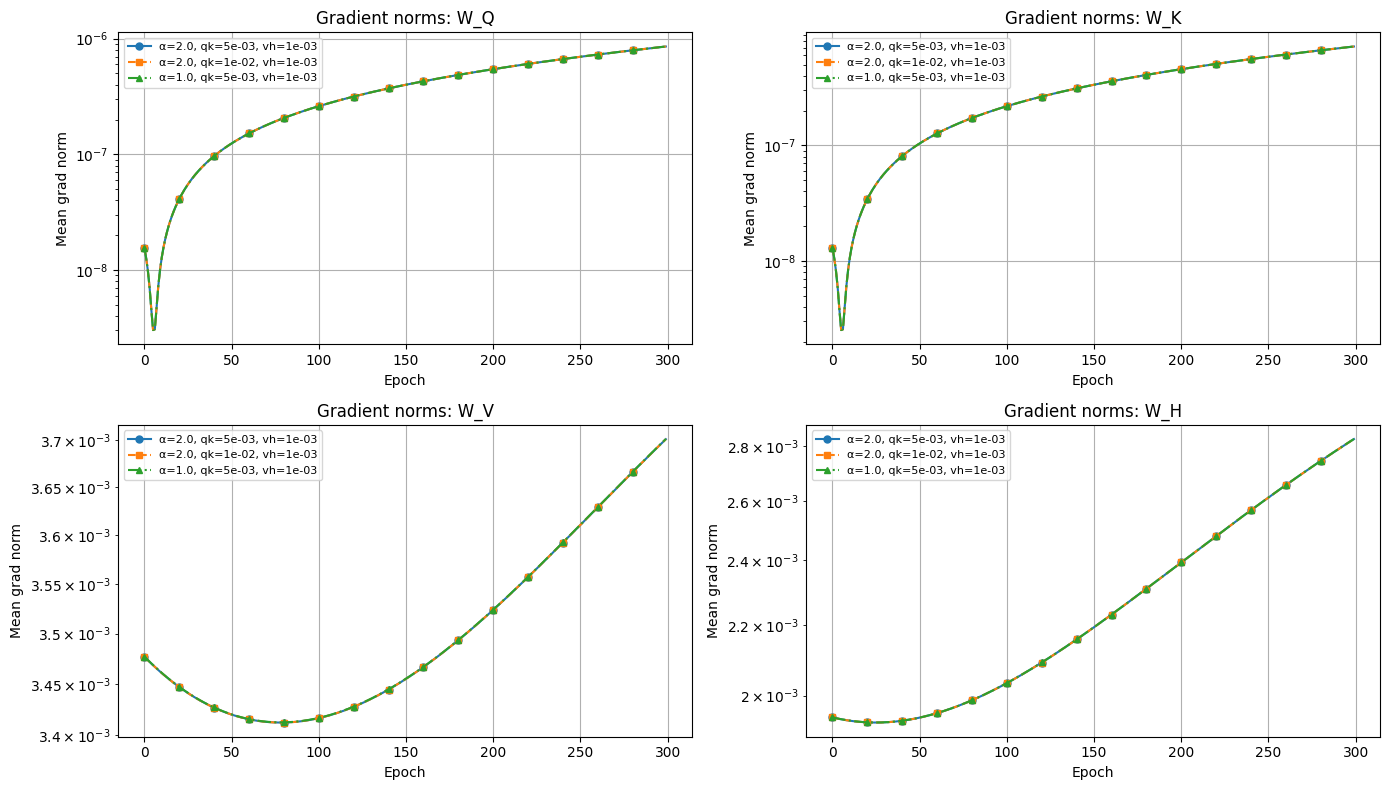

In [ ]:
# Experiment B configs — separate learning rates for Q/K vs V/H
configs_B = [
    {"alpha": 2.0, "epochs": 300, "lr_qk": 5e-3, "lr_vh": 1e-3, "clip": 1.0},
    {"alpha": 2.0, "epochs": 300, "lr_qk": 1e-2, "lr_vh": 1e-3, "clip": 1.0},
    {"alpha": 1.0, "epochs": 300, "lr_qk": 5e-3, "lr_vh": 1e-3, "clip": 1.0},
]

results_B = run_and_print(configs_B)
plot_results(results_B)